In [1]:
import warnings
warnings.filterwarnings("ignore")
from test_multicommodity import test_main, create_forcing, plot_result
from mcopt_misc import plot_network, run_mcopt
import sys
sys.path.append('../src/')
import numpy as np
from mcopt import McOpt, paris_topology
from typing import Dict, List, Tuple
import networkx as nx
import matplotlib.pyplot as plt

#### Compare With McOpt

In [2]:
def constrcut_mcopt(beta: float=1.0, method="paris"):
    method, coupling, museed, pflux, rho = method, "l1", 0, beta, 0.0   
    time_step, tot_time, relax_linsys, tau_cond_dyn, tau_cost_dyn = 0.5, 10000, 1.0e-5, 1.0e-1, 1.0e-1
    tau_cond_opt, tau_cost_opt = 1.0e-1, 1.0e-1
    VERBOSE = False
    mcopt = McOpt(method, coupling, museed, pflux, VERBOSE, rho, relax_linsys, tau_cond_dyn, tau_cost_dyn, time_step, tot_time, tau_cond_opt, tau_cost_opt)
    mcopt.ot_setup()
    return mcopt

In [3]:
def compare_mcopt_admk(beta: float=1.0, method="paris"):
    mcopt = constrcut_mcopt(beta=beta, method=method)
    forcing, conductivity_mcopt = run_mcopt(mcopt)
    topo, weights, forcing_ = mcopt.export_setup()
    potentials, conductivity_admk, potentials_admk = test_main(topo.copy(), weights, len(forcing_[0]), forcing_, beta=beta, max_iter=25)
    plot_network(mcopt.g, forcing, conductivity_mcopt, conductivity_admk)
    print(conductivity_admk[0])
    return mcopt.g, forcing_

* graph topology construction
* running [dynamics]
	convergence achieved [dynamics]
* export fluxes
* export cost
init signature: (self, tol_optimization=0.001, tol_constraint=1e-08, method='explicit_tdens', max_iter=200, max_restart=5, method_ctrl=None, verbose=0, log=0, log_file='admk.log', beta=1, log_print: bool = True)
ierr=0 avg_it=0010 max(res)=1.0e-08 max(pres)=8.8e-07
   -6.22e-01<=UPDATE<=1.11e+03, deltat=3.59e-03
ierr=0 avg_it=0011 max(res)=9.3e-09 max(pres)=5.4e-07
it=1 var=6.48e+01
   -8.28e-01<=UPDATE<=5.05e+02, deltat=3.19e-02
ierr=0 avg_it=0015 max(res)=9.7e-09 max(pres)=6.3e-07
it=2 var=1.97e+01
   -1.59e+00<=UPDATE<=1.68e+02, deltat=1.00e-01
ierr=0 avg_it=0015 max(res)=9.9e-09 max(pres)=8.1e-07
it=3 var=4.49e+00
   -1.65e+00<=UPDATE<=7.46e+01, deltat=1.00e-01
ierr=0 avg_it=0014 max(res)=9.5e-09 max(pres)=6.3e-07
it=4 var=1.81e+00
   -1.52e+00<=UPDATE<=5.16e+01, deltat=1.00e-01
ierr=0 avg_it=0014 max(res)=6.4e-09 max(pres)=5.2e-07
it=5 var=1.14e+00
   -1.39e+00<=UPDATE

ValueError: s must be a scalar, or float array-like with the same size as x and y

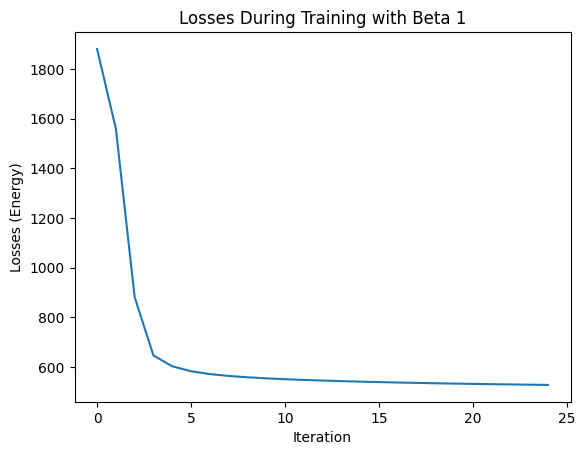

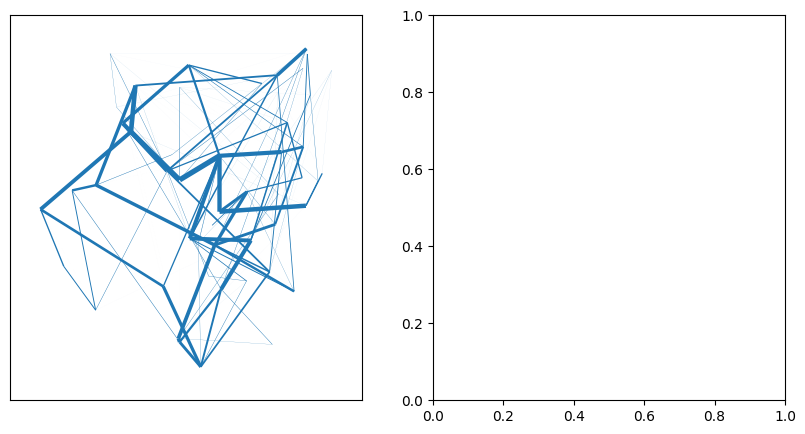

In [4]:
graph, forcing = compare_mcopt_admk(1, "synth")

###### Apply Fine-Grain Method On Waxman Graph

In [5]:
def discretize(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=20, beta=1, max_iter=20):
    def grid_coord_idx(coord: Tuple[int, int]): 
        return coord[0] * mesh_size + coord[1]
    
    mesh = nx.grid_2d_graph(mesh_size, mesh_size)
    num_commodity = len(mesh.nodes)
    forcing_grid = [np.zeros(num_commodity) for _ in range(mesh_size * mesh_size)]
    node_to_idx = {}
    for node in graph.nodes:
        cur_pos_on_grid: Tuple[int, int] = (round(graph.nodes[node]["pos"][0] * mesh_size), round(graph.nodes[node]["pos"][1] * mesh_size))
        print(f"Original pos: {graph.nodes[node]['pos']} | Pos on grid: {cur_pos_on_grid}")
        cur_pos_idx = grid_coord_idx(cur_pos_on_grid)
        node_to_idx[node] = cur_pos_idx
    for node in graph.nodes:
        for comm in range(len(graph.nodes)):
            forcing_grid[node_to_idx[node]][node_to_idx[comm]] += forcing[node][comm]
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[grid_coord_idx(node)])
    edge_lists = np.array([list((grid_coord_idx(e[0]), grid_coord_idx(e[1]))) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk, potentials_admk = test_main(edge_lists, weights, num_commodity, forcing_grid, beta=beta, max_iter=max_iter)
    plt.show()
    pos = {n: (n[0], n[1]) for n in mesh.nodes()}
    nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.1,  edge_color='C0', style='solid')
    amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
    nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
    plt.show()
    return mesh, conductivity_admk    

The scale of the `forcing` needs to be altered for different methods and topology, here we set it to `1e5`, which <ins>might not work</ins> for alternative problems (optimization might not run properly).

In [6]:
discretize(graph, forcing)

NameError: name 'graph' is not defined

We set beta to a different value to observe if the generated result has a different pattern.

**Conclusions**: 
1. It seems that we need to postprocess the result generating from the mesh. For instance, we need run some <inv>pruning algorithm</inv> to remove unnecessary edges (whose conductivity is so small), while maintaining the connectivity of the graph.
2. Though we are not allowed to provide the edge information, but if certain amount of mass is transferred from vertex $u$ to $v$, shaall we add weights of the edge that connect the paths between $u$ and $v$.

#### Triangular Lattice Graph

In [ ]:
def discretize_triangular(graph: nx.Graph, forcing: List[np.ndarray], mesh_size=17, beta=1, max_iter=20):
    X_SCALE, Y_SCALE = mesh_size - 1, (mesh_size - 1) * (np.sqrt(3) / 2)
    mesh = nx.triangular_lattice_graph(mesh_size, mesh_size * 2)
    num_commodity = len(mesh.nodes()) 
    nodes_list = list(mesh.nodes())          
    key_to_index = {key: idx for idx, key in enumerate(nodes_list)}
    idx_to_key = {idx: key for key, idx in key_to_index.items()}
    
    def coordinate_to_key(coord):
        y = int(coord[1] / (np.sqrt(3) / 2) + 0.5)
        x = round(coord[0]) if y % 2 == 0 else round(coord[0] - 0.5)
        return (x, y)

    forcing_grid = [np.zeros(num_commodity) for _ in range(len(mesh.nodes()))]
    print(f"Size of the forcing grid is {len(forcing_grid)}")
    node_to_index = {}
    for node in graph.nodes:
        raw_pos = (graph.nodes[node]["pos"][0] * X_SCALE, graph.nodes[node]["pos"][1] * Y_SCALE)
        key = coordinate_to_key(raw_pos)
        index = key_to_index[key]
        node_to_index[node] = index
    for node in graph.nodes:
        for comm in range(len(graph.nodes)):
            forcing_grid[node_to_index[node]][node_to_index[comm]] += forcing[node][comm]
    for node in mesh.nodes():
        mesh.nodes[node]["amplitude"] = np.linalg.norm(forcing_grid[key_to_index[node]])
    edge_lists = np.array([list((key_to_index[e[0]], key_to_index[e[1]])) for e in mesh.edges()])
    weights = np.ones_like(edge_lists[:,0])
    potentials, conductivity_admk, potentials_admk = test_main(edge_lists, weights, num_commodity, forcing_grid, beta=beta, max_iter=max_iter)
    # for cpot in potentials: print(cpot[0:20])
    plt.show()
    pos = {n: (n[0], n[1]) for n in mesh.nodes()}
    nx.draw_networkx_edges(mesh, pos=pos, width=np.array(conductivity_admk) * 0.2,  edge_color='C0', style='solid')
    amps = [mesh.nodes[n]['amplitude']  for n in mesh.nodes()]
    nx.draw_networkx_nodes(mesh, pos=pos, node_size=amps, node_color='orange')
    plt.show()
    return mesh, conductivity_admk 

In [ ]:
discretize_triangular(graph, forcing, beta=1)